In [2]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from glob import glob as gg
from zipfile import ZipFile
from keras.optimizers import Adam
from keras.models import load_model
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint
from keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

In [3]:
data = "symbol_images"

assert os.path.exists(data)

In [4]:
dataset = tf.keras.utils.image_dataset_from_directory(
    data, image_size = (64, 64), batch_size = 64
)

Found 701773 files belonging to 53 classes.


In [4]:
print(type(dataset))

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [5]:
data_itr = dataset.as_numpy_iterator()

In [6]:
batch = data_itr.next()

In [7]:
batch[0].shape

(64, 64, 64, 3)

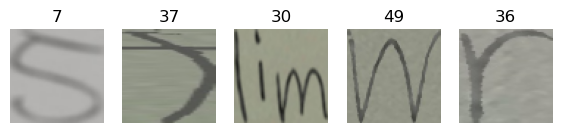

In [8]:
num = np.random.randint(0, 58)

fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
for idx, img in enumerate(batch[0][num:num + 5]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][num])
    ax[idx].axis("off")
    num += 1

In [5]:
def image_processing(image, label):

    image = tf.cast(image / 255.0, tf.float32)

    return image, label

In [6]:
processed_data = dataset.map(image_processing)

processed_data = processed_data.shuffle(buffer_size = 1000, seed = 42)

In [7]:
train_size = int(len(processed_data) * 0.7)
test_size = int(len(processed_data) * 0.2)
val_size = int(len(processed_data) * 0.1) + 1

assert train_size + test_size + val_size == len(processed_data)

len(processed_data), train_size, test_size, val_size

(10966, 7676, 2193, 1097)

In [8]:
train = processed_data.take(train_size)
test = processed_data.skip(train_size).take(test_size)
val = processed_data.skip(train_size + test_size).take(val_size)

In [9]:
assert len(train) + len(test) + len(val) == len(processed_data)

In [10]:
train = train.prefetch(buffer_size = tf.data.AUTOTUNE)
test = test.prefetch(buffer_size = tf.data.AUTOTUNE)
val = val.prefetch(buffer_size = tf.data.AUTOTUNE)

In [ ]:
seg_model = Sequential([
    Conv2D(
        filters = 32, kernel_size = (3, 3),
        activation = 'relu', input_shape = (64, 64, 3)
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (3, 3)),
    Conv2D(
        filters = 64, kernel_size = (2, 2),
        activation = 'relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (2, 2)),
    Conv2D(
        filters = 128, kernel_size = (2, 2),
        activation = 'relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (2, 2)),
    Conv2D(
        filters = 64, kernel_size = (2, 2),
        activation = 'relu'
    ),
    BatchNormalization(),
    MaxPooling2D(pool_size = (2, 2)),
    Flatten(),
    Dense(units = 32, activation = 'relu'),
    Dropout(rate = 0.3),
    Dense(units = 53, activation = 'softmax')
])

/home2/va23abb/miniconda3/envs/myenv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
best_weight_cb = ModelCheckpoint(
    filepath = 'models/symbol_model.keras',
    monitor = 'val_accuracy',
    verbose = 1,
    save_best_only = True
)

In [35]:
seg_model.compile(
    optimizer = Adam(learning_rate = 0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [36]:
seg_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 19, 19, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 19, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 3, 3, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 53)             │         1,749 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,861 (311.96 KB)

 Trainable params: 79,285 (309.71 KB)

 Non-trainable params: 576 (2.25 KB)

In [37]:
seg_model = seg_model.fit(
    train,
    validation_data = val,
    batch_size = 64,
    epochs = 65,
    verbose = 1,
    callbacks = [best_weight_cb]
)

Epoch 1/65
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6297 - loss: 1.3534
Epoch 1: val_accuracy improved from -inf to 0.76238, saving model to models/symbol_model.keras
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 73s 9ms/step - accuracy: 0.6297 - loss: 1.3533 - val_accuracy: 0.7624 - val_loss: 0.7758
Epoch 2/65
7675/7676 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8030 - loss: 0.6424
Epoch 2: val_accuracy did not improve from 0.76238
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 66s 8ms/step - accuracy: 0.8030 - loss: 0.6424 - val_accuracy: 0.6954 - val_loss: 1.2155
Epoch 3/65
7666/7676 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8247 - loss: 0.5639
Epoch 3: val_accuracy improved from 0.76238 to 0.78942, saving model to models/symbol_model.keras
7676/7676 ━━━━━━━━━━━━━━━━━━━━ 65s 8ms/step - accuracy: 0.8247 - loss: 0.5639 - val_accuracy: 0.7894 - val_loss: 0.6972
Epoch 4/65
7674/7676 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8391 - loss: 0.5152
Epoch 4: val_accuracy improved from 0.78942 

In [12]:
model = load_model("models/symbol_model_03.keras")

In [16]:
model_test = model.evaluate(test)

2025-04-29 12:38:10.856584: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] ShuffleDatasetV3:8: Filling up shuffle buffer (this may take a while): 793 of 1000
2025-04-29 12:38:13.749876: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:482] Shuffle buffer filled.


2193/2193 ━━━━━━━━━━━━━━━━━━━━ 222s 48ms/step - accuracy: 0.9335 - loss: 0.1979


In [17]:
# [0.1982913762331009, 0.9332820177078247]

loss = model_test[0] # ["loss"]
accuracy = model_test[1] # ["accuracy"]

print(f"Test loss: {loss} \n Test accuracy: {accuracy}")

Test loss: 0.19771212339401245 
 Test accuracy: 0.9337736368179321


In [62]:
with open('models/seg_training_history_02.json', 'w') as file:
    json.dump(seg_model.history, file)

In [38]:
history = seg_model.history

In [39]:
train_accuracy = history["accuracy"]
val_accuracy = history["val_accuracy"]
train_loss = history["loss"]
val_loss = history["val_loss"]

In [55]:
from matplotlib import rcParams

dpi = 200 # 200-300 as per guidelines
maxpix = 670  # max pixels of plot
width = maxpix / dpi  # max allowed width
rcParams.update({'axes.labelsize': 'large', 'axes.titlesize': 'x-large',  # the size of labels and title
                 'xtick.labelsize': 'large', 'ytick.labelsize': 'large',  # the size of the axes ticks
                 'legend.fontsize': 'x-small', 'legend.frameon': False,  # legend font size, no frame
                 'legend.facecolor': 'none', 'legend.handletextpad': 0.25,
                 # legend no background colour, separation from label to point
                 'font.serif': ['Arial'],  # default fonts to try and use
                 'font.family': 'serif',  # use serif fonts
                 'mathtext.fontset': 'cm', 'mathtext.default': 'regular',  # if in math mode, use these
                 'figure.figsize': [0.4 * width,  (0.3 * width)], 'figure.dpi': dpi,
                 
                'text.color' : "black", 'axes.labelcolor' : "black",'axes.facecolor': 'white',
                 'xtick.color':'black', 'ytick.color':'black', 'figure.facecolor':'none',
                 
                 # the figure size in inches and dots per inch
                 'lines.linewidth': .75,  # width of plotted lines
                 'xtick.top': True, 'ytick.right': True,  # ticks on right and top of plot
                 'xtick.minor.visible': True, 'ytick.minor.visible': True,  # show minor ticks
                 'text.usetex': False, 'xtick.labelsize':'large',
                 'ytick.labelsize':'large'})

findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


Path exists!


findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


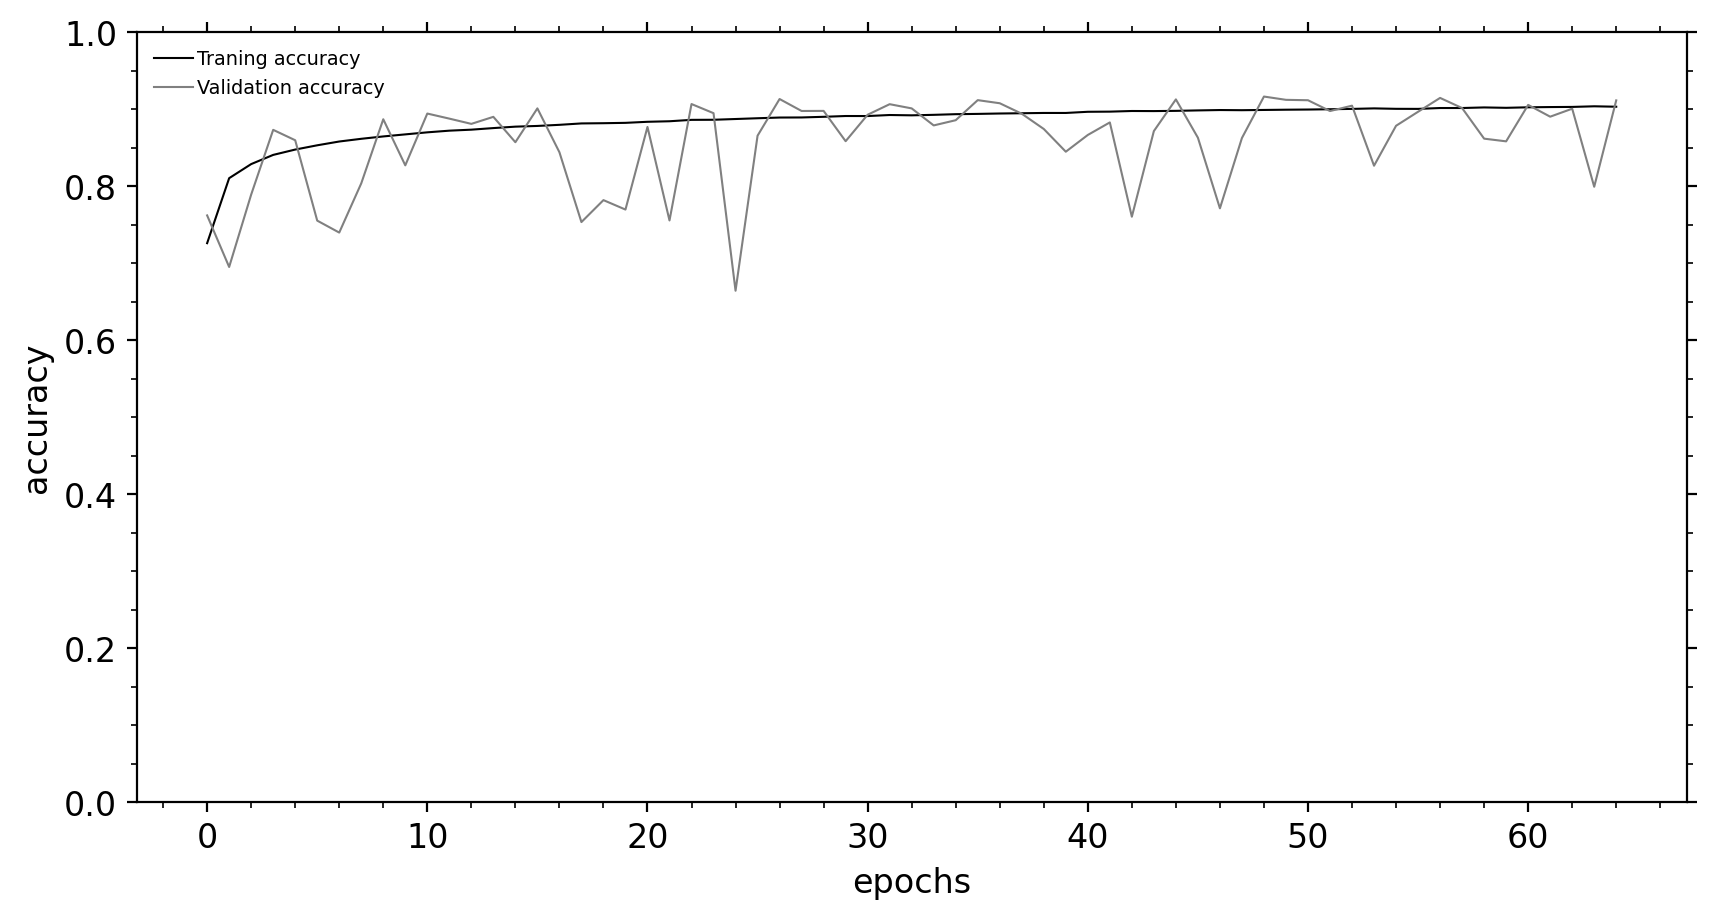

In [56]:
plt.figure(figsize = (10, 5))

plt.plot(train_accuracy, label = "Traning accuracy", color = 'k')
plt.plot(val_accuracy, label = "Validation accuracy", color = "grey")

plt.xlabel("epochs")
plt.ylabel("accuracy")

plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

# plt.title("Traning and Validation Accuracy")
plt.legend()

path = "charts/"
print("Path exists!") if os.path.exists(path) else os.mkdir(path)
count = len(gg(f"{path}/accuracy*.png"))

plt.savefig(os.path.join(path, f"accuracy_{count}.png"))
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


Path exists!


findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial
findfont: Generic family 'serif' not found because none of the following families were found: Arial


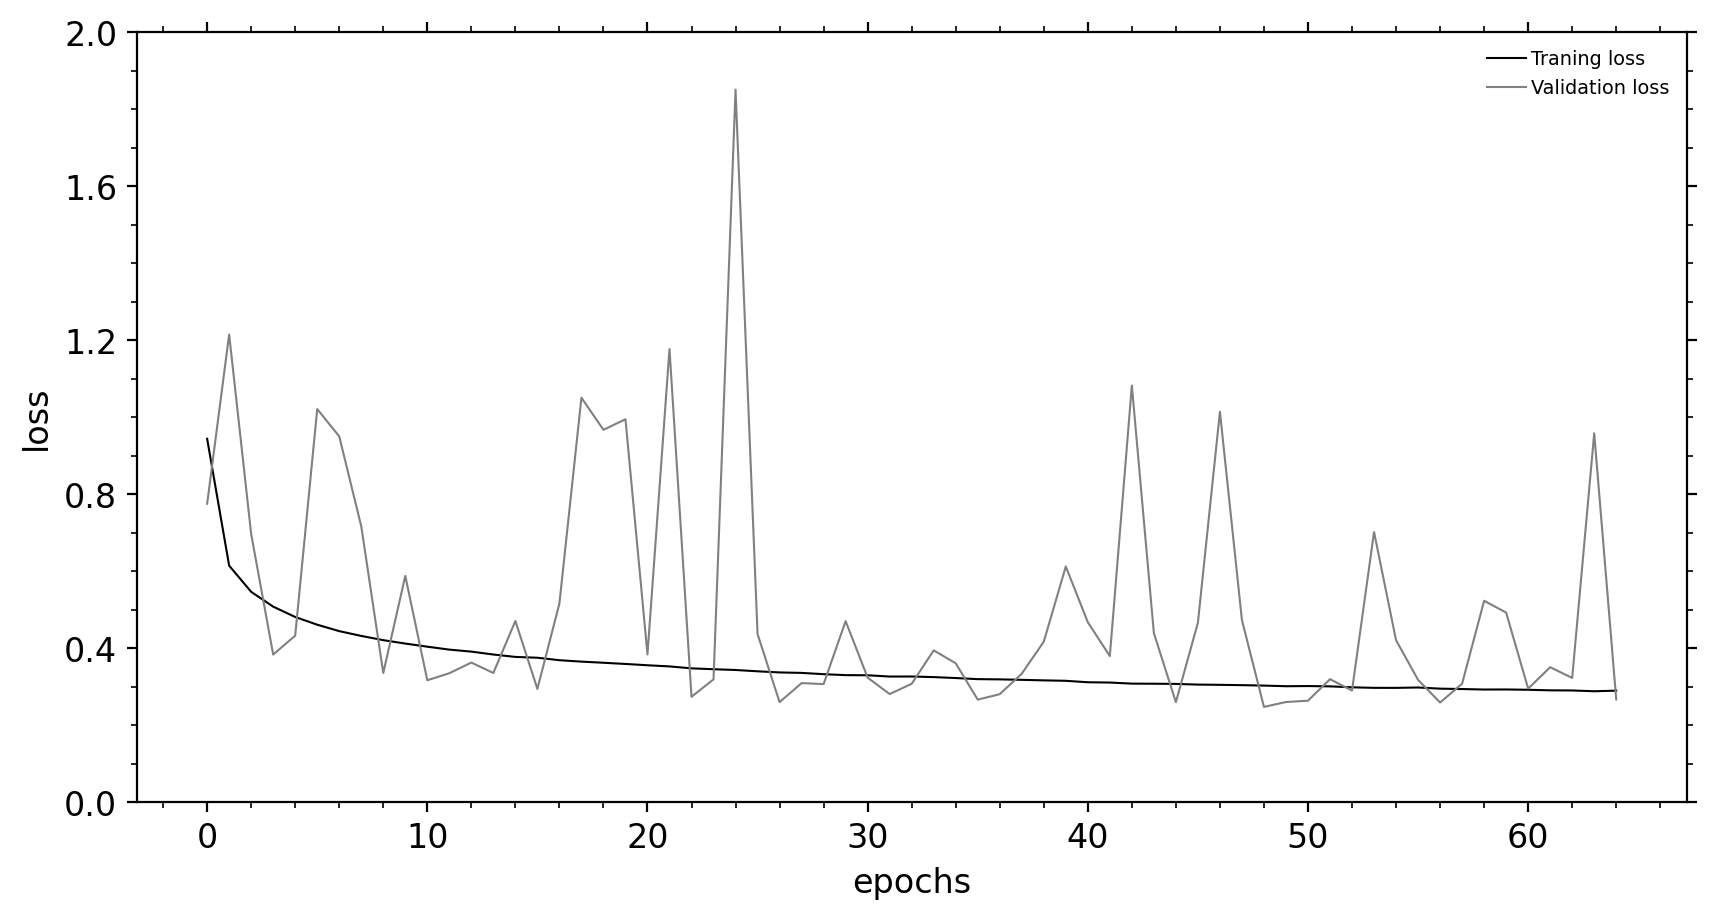

In [58]:
plt.figure(figsize = (10, 5))
plt.plot(train_loss, label = "Traning loss", color = 'k')
plt.plot(val_loss, label = "Validation loss", color = "grey")
plt.xlabel("epochs")
plt.ylabel("loss")

plt.yticks([0, 0.4, 0.8, 1.2, 1.6, 2])

# plt.title("Traning and Validation Loss")
plt.legend()
path = "charts/"
print("Path exists!") if os.path.exists(path) else os.mkdir(path)
count = len(gg(f"{path}/loss*.png"))
plt.savefig(os.path.join(path, f"loss_{count}.png"))
plt.show()

In [ ]:
seg_model = load_model("models/symbol_model.keras")

In [14]:
sample_data = batch[0][:5]

predictions = seg_model.predict(sample_data)
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted classes:", predicted_classes)

fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
for idx, img in enumerate(batch[0][:5]):
    # ax[idx].imshow(img)
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][num])
    ax[idx].axis("off")
    num += 1

NameError: name 'batch' is not defined